# Tutorial 3: Filter Traces with `trace_filter`

## Objective

`trace_filter` lets you remove unwanted data from a trace file using simple command-line options.
This tutorial demonstrates three common filtering scenarios:

1. **Spatial filtering** — restrict X, Y, or Z coordinate ranges
2. **Remove a problematic barcode** — identified from Tutorial 2 QC
3. **Minimum barcode count** — keep only traces with enough detections

Other options (`--keep_label`, `--remove_label`, `--clean_spots`) are covered in later tutorials.

## Input

The merged trace file produced by Tutorial 1: `merged_traces.ecsv`

In [25]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

data_path = "/mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ"
dest_path = f"{data_path}/output"

# Input: merged trace file from Tutorial 1
input_trace = f"{dest_path}/merged_traces_filtered_cleaned.ecsv"

print(f"Input:  {input_trace}")
print(f"Output: {dest_path}")

Input:  /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces_filtered_cleaned.ecsv
Output: /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output


## Example 1: Spatial Filtering (X, Y, Z)

Use `--z_min` / `--z_max` (and similarly `--x_min`, `--x_max`, `--y_min`, `--y_max`) to restrict coordinate ranges.
This is useful when you know certain Z-planes are out of focus, or that localizations near image borders are unreliable.

In practice, spatial filtering is **rarely needed** — most artifacts are better handled by barcode-level or trace-level filters.
We show it here for completeness.

Let's restrict Z to the [3.0, 11.0] µm range (removes ~5% of extreme outliers based on Tutorial 2 QC):

In [26]:
!trace_filter --input {input_trace} --z_min 0.5 --z_max 9.0 -O z_filtered

------- Running trace_filter.py --------
Filter chromatin trace files.

==========Started execution==========

$ trace files to process: ['/mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces_filtered_cleaned.ecsv']

$ trace files to process= ['/mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces_filtered_cleaned.ecsv']
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces_filtered_cleaned.ecsv

$ Filtering duplicated barcodes

$ Filtering barcodes based on coordinates

$ Will keep localizations with 0.5 < z < 9.0.
$ Number of original spots / traces: 326271 / 5148
$ Number of spots to remove: 0
$ Number of spots / traces left: 326271 / 5148

$ Filtering barcodes based on intensity

$ Filtering barcode number

$ Removing traces with < 2 spots
$ Number of original spots / traces: 3

The filtered file is saved alongside the input with the tag appended: `merged_traces_z_filtered.ecsv`.

You can combine multiple coordinate filters in a single command:
```bash
trace_filter --input Trace.ecsv --z_min 3.0 --z_max 11.0 --y_min 100 --y_max 400
```

> **Note:** We won't use this spatial-filtered file for the rest of the tutorial. The examples below start from the original `merged_traces.ecsv` to keep each example independent.

## Example 2: Remove a Problematic Barcode

In Tutorial 2, the **Barcode Detection Efficiency** plot showed that **barcodes 84, 65 and 36** has a low detection rate.
A barcode detected in so few traces adds noise without contributing useful signal.

Use `--remove_barcode` to exclude it:

In [24]:
!trace_filter --input {input_trace} --remove_barcode 84,49,65,36 -O no_bcd84_49_65_36

------- Running trace_filter.py --------
Filter chromatin trace files.

==========Started execution==========

$ trace files to process: ['/mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces.ecsv']

$ trace files to process= ['/mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces.ecsv']
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces.ecsv

$ Filtering duplicated barcodes

$ Filtering barcodes based on coordinates

$ Removing user provided barcodes: ['84', '49', '65', '36']
$ Removing barcode <84>
$ Found barcode: [np.int64(84)]
$ Number of spots to remove: 1881

$ Number of barcodes 
	 original: 86 
	 after: 85
$ Removing barcode <49>
$ Found barcode: [np.int64(49)]
$ Number of spots to remove: 4991

$ Number of barcodes 
	 original: 85 
	 after: 84
$ Removing barcode <65>
$

You can remove multiple barcodes at once with a comma-separated list:
```bash
trace_filter --input Trace.ecsv --remove_barcode 84,65,36
```

## Example 3: Keep Only Traces with Enough Barcodes

The most impactful filter is `--n_barcodes`: it keeps only traces that have at least N barcode detections.
Short traces (1–3 barcodes) carry little structural information and inflate downstream analyses.

From Tutorial 2's **Trace Statistics** plot, the median trace length is 3 barcodes.
Let's set a threshold of **4 barcodes** to keep the more informative half of the data.

We'll run `trace_analyzer` **before and after** filtering to compare the impact.

### Before filtering

In [13]:
# Run QC on the unfiltered data (reference)
!trace_analyzer --input {input_trace}

------- Running trace_analyzer.py --------
Analyze chromatin trace files.


1 trace files to process= /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces.ecsv
> Analyzing traces for /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces.ecsv
$ Number of spots in trace file: 326310
$ Calculating overall barcode detection across 5161 traces...
$ Exporting barcode detection plot to: /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces_barcode_detection.png
$ Saved neighbor distances plot: /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces_first_neighbor_distances.png
$ Mean distances between neighboring barcodes: X=-0.609, Y=-0.021,

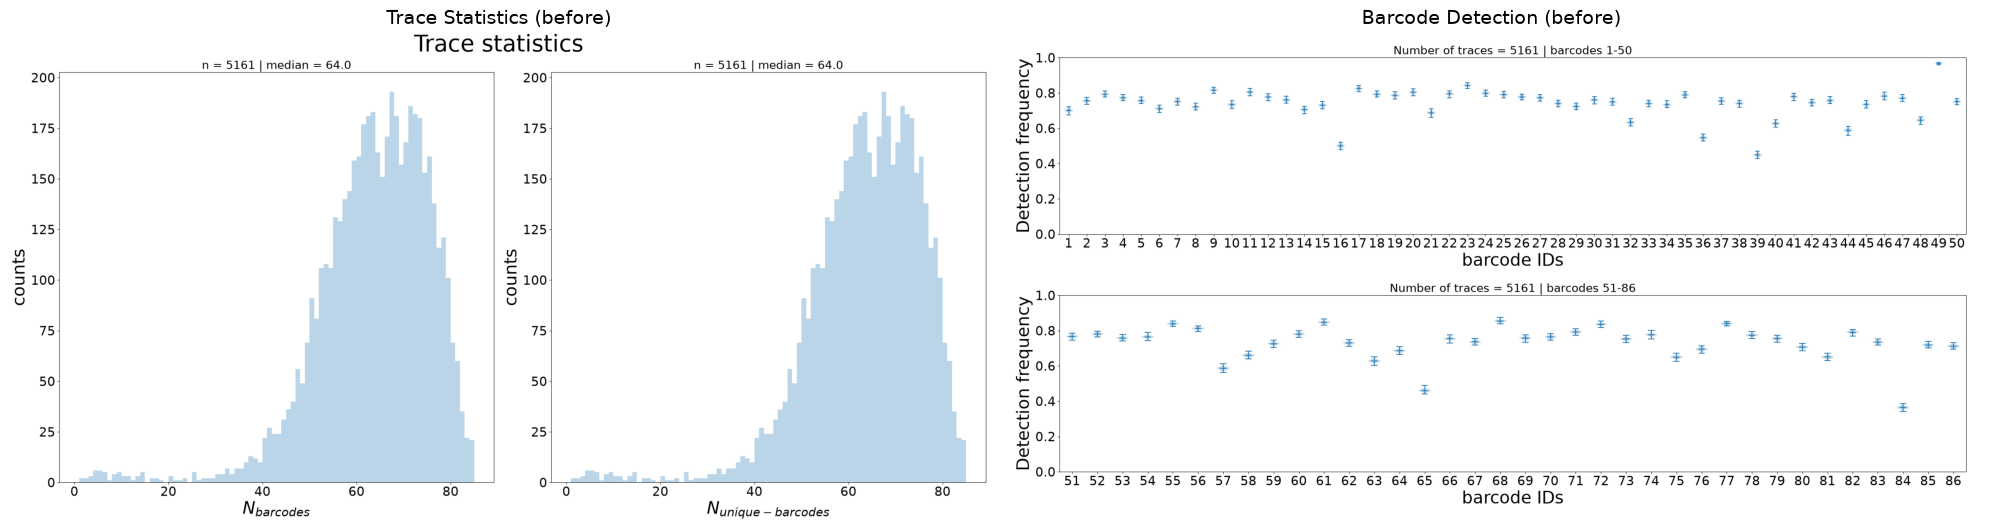

In [14]:
# Display reference plots
before_stats = f"{dest_path}/merged_traces_trace_statistics.png"
before_detect = f"{dest_path}/merged_traces_barcode_detection.png"

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, f, title in zip(axes, [before_stats, before_detect],
                         ["Trace Statistics (before)", "Barcode Detection (before)"]):
    ax.imshow(mpimg.imread(f))
    ax.set_title(title, fontsize=14)
    ax.axis('off')
plt.tight_layout()
plt.show()

### Apply the filter

In [18]:
# Keep only traces with >= 4 barcodes

!trace_filter --input {input_trace} --n_barcodes 4 -O filtered

------- Running trace_filter.py --------
Filter chromatin trace files.

==========Started execution==========

$ trace files to process: ['/mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces.ecsv']

$ trace files to process= ['/mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces.ecsv']
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces.ecsv

$ Filtering duplicated barcodes

$ Filtering barcodes based on coordinates

$ Filtering barcodes based on intensity

$ Filtering barcode number

$ Removing traces with < 4 spots
$ Number of original spots / traces: 326310 / 5161
$ Analyzing traces...
$ Number of traces to remove: 7
$ Finding which rows to remove...
$ Number of spots / traces left: 326295 / 5154
$ Saving output table as /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_For

### After filtering

In [19]:
# Run QC on the filtered data
filtered_trace = f"{dest_path}/merged_traces_filtered.ecsv"
!trace_analyzer --input {filtered_trace}

------- Running trace_analyzer.py --------
Analyze chromatin trace files.


1 trace files to process= /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces_filtered.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces_filtered.ecsv
> Analyzing traces for /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces_filtered.ecsv
$ Number of spots in trace file: 326295
$ Calculating overall barcode detection across 5154 traces...
$ Exporting barcode detection plot to: /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces_filtered_barcode_detection.png
$ Saved neighbor distances plot: /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces_filtered_first_neighbor_distances.png
$ Mean distances betw

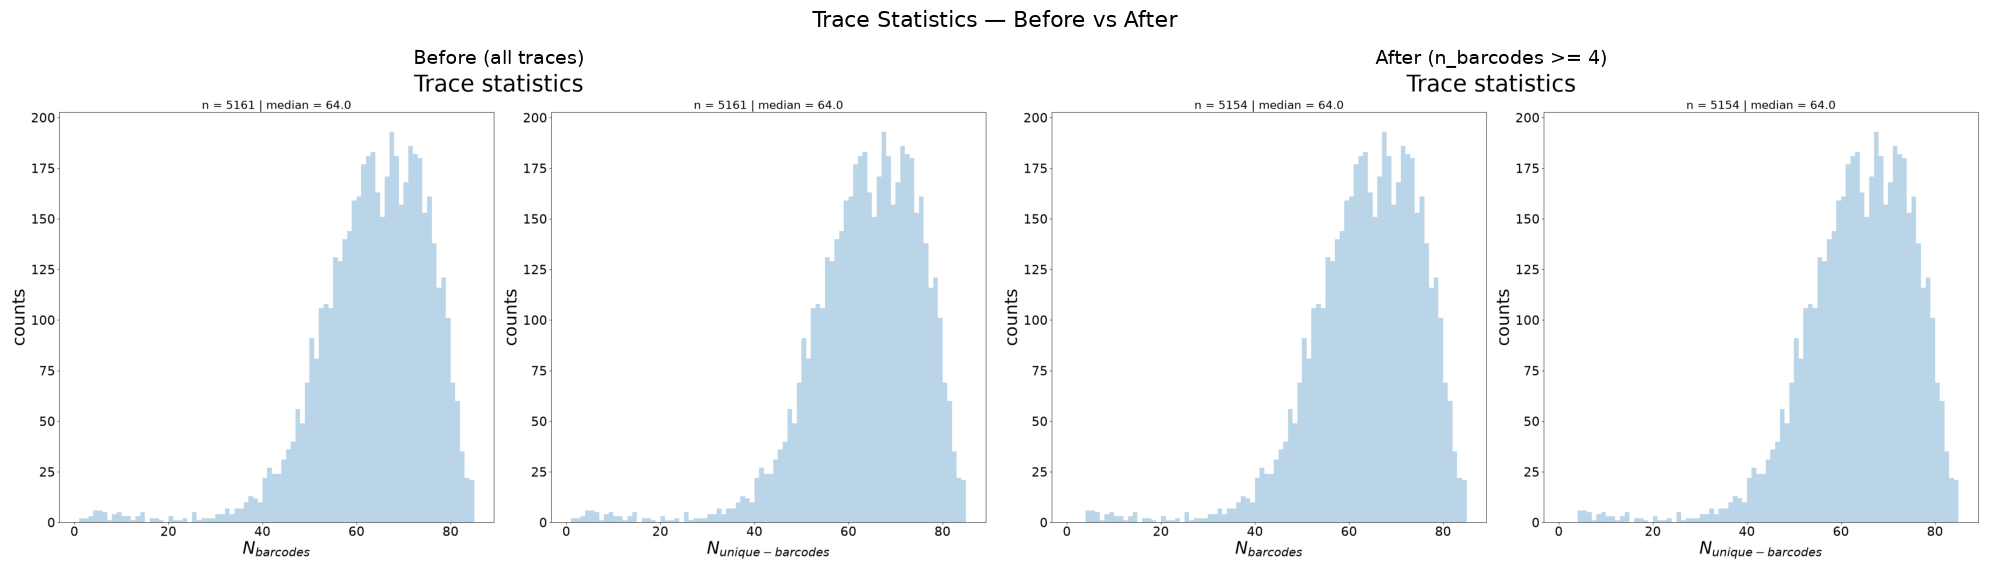

In [20]:
# Compare before vs after: Trace Statistics
after_stats = f"{dest_path}/merged_traces_filtered_trace_statistics.png"

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, f, title in zip(axes, [before_stats, after_stats],
                         ["Before (all traces)", "After (n_barcodes >= 4)"]):
    ax.imshow(mpimg.imread(f))
    ax.set_title(title, fontsize=14)
    ax.axis('off')
fig.suptitle("Trace Statistics — Before vs After", fontsize=16)
plt.tight_layout()
plt.show()

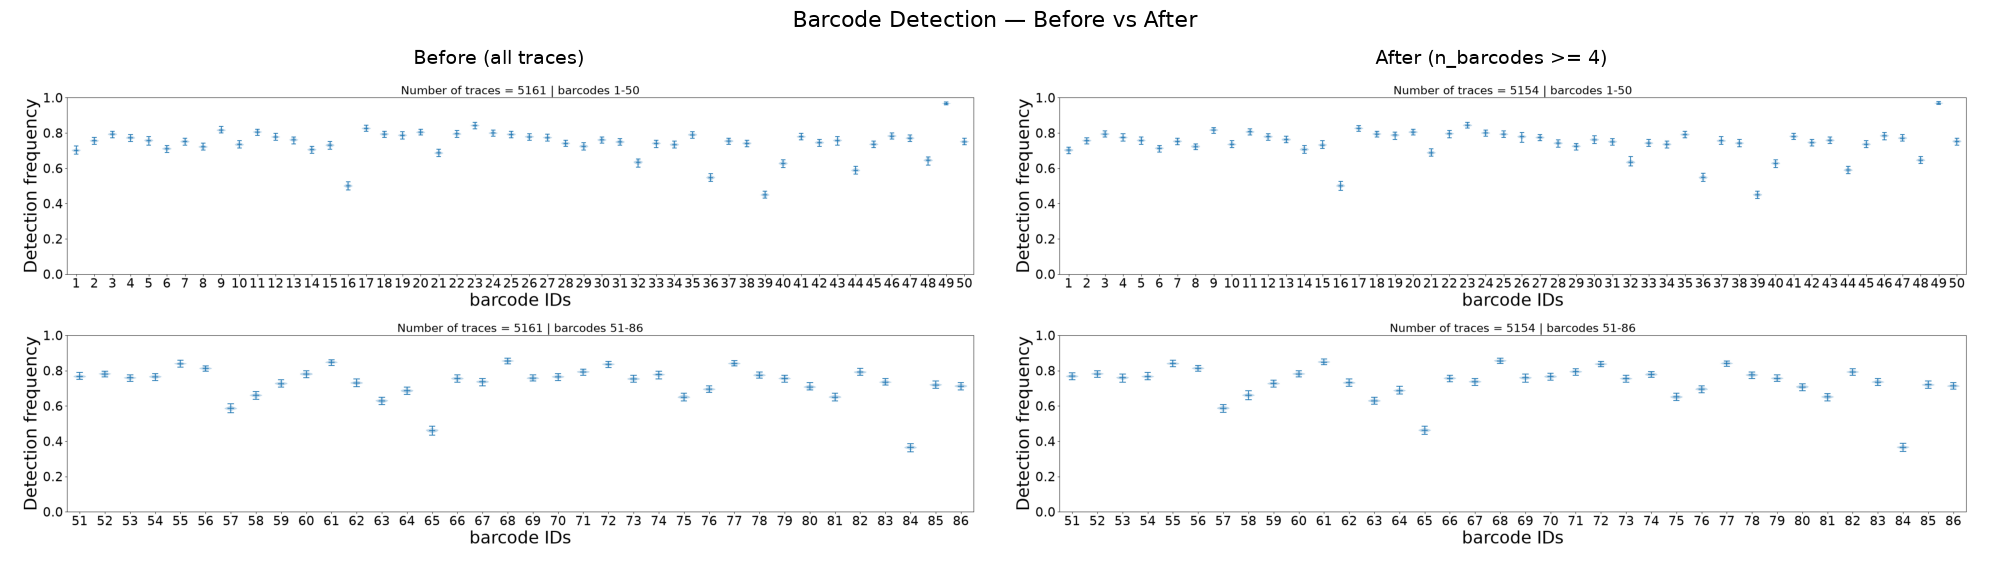

In [22]:
# Compare before vs after: Barcode Detection
after_detect = f"{dest_path}/merged_traces_filtered_barcode_detection.png"

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, f, title in zip(axes, [before_detect, after_detect], ["Before (all traces)", "After (n_barcodes >= 4)"]):
    ax.imshow(mpimg.imread(f))
    ax.set_title(title, fontsize=14)
    ax.axis('off')
fig.suptitle("Barcode Detection — Before vs After", fontsize=16)
plt.tight_layout()
plt.show()

The before/after comparison shows:
- **Trace Statistics**: the left tail (1–3 barcode traces) is removed, shifting the distribution toward longer, more informative traces
- **Barcode Detection**: detection frequencies increase because short traces (which had few barcodes by definition) are excluded

> **Tip:** Try different `--n_barcodes` thresholds (3, 5, 8...) and compare the plots to find the right balance between data quantity and quality for your experiment.

## Combining Filters

All options can be combined in a single command. For example:

```bash
trace_filter --input merged_traces.ecsv \
    --z_min 3.0 --z_max 11.0 \
    --remove_barcode 27 \
    --n_barcodes 4 \
    -O filtered
```

Filters are applied in this order: coordinates → barcode removal → barcode count.
The `--n_barcodes` filter is applied **last** because earlier filters may shorten traces.

## Summary

| Filter | Option | When to Use |
|--------|--------|-------------|
| Spatial range | `--z_min`, `--z_max`, `--x_min`... | Known out-of-focus planes or border artifacts |
| Remove barcode | `--remove_barcode 27` | Low detection efficiency (see Tutorial 2 QC) |
| Min. barcodes | `--n_barcodes 4` | Remove short, uninformative traces |

### Other `trace_filter` options (covered in later tutorials)

| Option | Tutorial |
|--------|----------|
| `--clean_spots` | Tutorial 4 — Filter Duplicates |
| `--keep_label` / `--remove_label` | Tutorial 6 — Assign Masks & Split Labels |

**Next:** [Tutorial 4 — Filter Duplicate Barcodes](tutorial_04_filter_duplicates.ipynb)